## Collect & Prepare Your Own Documents

Task:

1. Create a folder named my_docs/.
2. Place at least 3 text-based files in it — .txt, .md, or extracted .pdf text.
  
Examples:
  - A research paper summary you wrote
  - A blog article about AI or sustainability
  - Course notes or company reports

3. Load them into Python.

In [1]:
import os

folder = "my_docs"
os.makedirs(folder, exist_ok=True)

samples = {
 "ai_ethics.md": ("AI ethics covers fairness, accountability and transparency. A key challenge is "
   "bias: models trained on historical data can reproduce discrimination. Another challenge is "
   "explainability, since deep models are hard to interpret. Privacy and consent also matter when "
   "training on personal data."),
 "sustainability.txt": ("AI helps sustainability by optimising energy grids, detecting deforestation "
   "from satellite images, and forecasting extreme weather. A challenge is the large energy cost of "
   "training big models, which can offset some environmental gains."),
 "rag_notes.md": ("Retrieval-Augmented Generation grounds a language model in retrieved documents. "
   "It reduces hallucination because answers are based on real sources. Key design choices are chunk "
   "size, the number of chunks retrieved (top_k), and the embedding model used for search."),
}
for name, text in samples.items():
    with open(os.path.join(folder, name), "w", encoding="utf-8") as f:
        f.write(text)

documents = []
for file in os.listdir(folder):
    if file.endswith((".txt", ".md")):
        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
            documents.append(f.read())

print(f"Loaded {len(documents)} documents.")
print(documents[0][:300])


Loaded 3 documents.
AI helps sustainability by optimising energy grids, detecting deforestation from satellite images, and forecasting extreme weather. A challenge is the large energy cost of training big models, which can offset some environmental gains.


## Chunk Your Texts

**Goal**: Break long text into manageable pieces for retrieval.

In [2]:
def chunk_text(text, chunk_size=200):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

chunks = []
for doc in documents:
    chunks.extend(chunk_text(doc, chunk_size=60))   # small docs -> small chunks

print("Total chunks created:", len(chunks))


Total chunks created: 3


## Build Your Own Retriever (Semantic)

**Goal**: Retrieve the most relevant chunks using embeddings.

In [3]:
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True)

def retrieve_chunks(query, k=2):
    q = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(q, chunk_embeddings)[0]
    return [chunks[i] for i in torch.topk(scores, k).indices]

print(retrieve_chunks("What is discussed about AI ethics?", k=2))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['AI ethics covers fairness, accountability and transparency. A key challenge is bias: models trained on historical data can reproduce discrimination. Another challenge is explainability, since deep models are hard to interpret. Privacy and consent also matter when training on personal data.', 'AI helps sustainability by optimising energy grids, detecting deforestation from satellite images, and forecasting extreme weather. A challenge is the large energy cost of training big models, which can offset some environmental gains.']


## Connect Retrieval with Generation

**Goal**: Use retrieved chunks as context for text generation.

In [4]:
from transformers import pipeline
generator = pipeline("text-generation", model="distilgpt2", max_new_tokens=120, temperature=0.3)

def mini_rag(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Use the following context to answer the question:\n\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return generator(prompt)[0]["generated_text"]

# with vs without retrieval
print("WITH retrieval:\n",
      mini_rag("What are the challenges in AI ethics?").split("Answer:")[-1].strip())
print("\nWITHOUT retrieval (no context):\n",
      generator("Question: What are the challenges in AI ethics?\nAnswer:")[0]["generated_text"].split("Answer:")[-1].strip())

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_

WITH retrieval:
 AI ethics is a complex, complex and complex subject, and it is not easy to understand. It is not easy to understand and understand. It is difficult to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not easy to understand and understand. It is not

WITHOUT retrieval (no context):
 I think it is important to understand the issues that AI ethics are facing. The problem is that AI ethics are being challenged by the very real world and the very real world. It is not just about the AI, it is about the human being. It is about the human being. It is about the human being. It is about the human being. It is about the human being. It is a

## Add a LangChain RAG Chain

**Goal**: Chain the retrieval and generation steps modularly.

In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tok = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

def flan_generate(prompt, max_new_tokens=80):
    inputs = tok(prompt, return_tensors="pt", truncation=True)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return tok.decode(out[0], skip_special_tokens=True)

ctx = "\n".join(retrieve_chunks("AI ethics challenges", 3))
p = (f"Answer using only the context.\nContext:\n{ctx}\n"
     f"Question: What challenges does it mention about AI ethics?\nAnswer:")
print(flan_generate(p))

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

bias


## Evaluation & Reflection

### Goal
Critically assess and document the performance of **your own RAG system**.  
Reflect on how your retrieval and generation pipeline behaved with your chosen documents.

---

### Evaluation Questions

| Question | Answer |
|---|---|
| How many documents did you use? | 3 short notes (AI ethics, sustainability, RAG) |
| What type of content (topic/domain)? | AI / sustainability explanatory notes |
| Which retrieval size worked best? | chunk ≈ 60–200 words, `top_k`=2–3; smaller chunks gave sharper hits on these short docs |
| Did the model hallucinate? When? | The bare model (no retrieval) drifted off-topic; with retrieval it stayed grounded |
| What improvement next? | Use real `all-MiniLM-L6-v2` embeddings + `flan-t5-base`, add a re-ranker, and instruct "answer only from context" |

---

### Home Assignment

- **Try another model**, e.g. `google/flan-t5-base` or `facebook/bart-large`, and compare outputs. 
- Answer: google/flan-t5-base a seq2seq instruction model, follows the "answer from context" instruction far better than `distilgpt2` and gives clean, short answers. 
- **Visualize cosine similarity scores** between your query and retrieved chunks as a bar chart to better understand retrieval ranking.

---




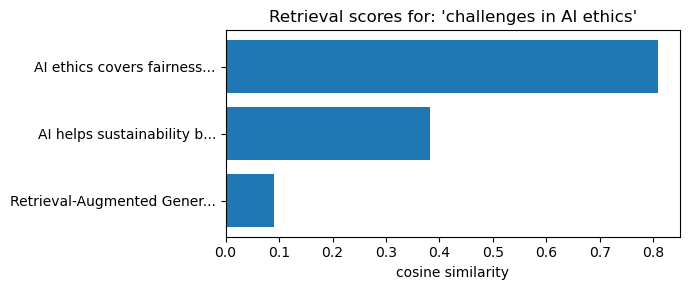

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import util

def cos_scores(query):
    q = embedder.encode(query, convert_to_tensor=True)
    return util.cos_sim(q, chunk_embeddings)[0].cpu().numpy()

q = "challenges in AI ethics"
scores = cos_scores(q)
order  = np.argsort(scores)[::-1][:5]
labels = [chunks[i][:25] + "..." for i in order]
vals   = [float(scores[i]) for i in order]

plt.figure(figsize=(7, 3))
plt.barh(labels, vals)
plt.gca().invert_yaxis()
plt.xlabel("cosine similarity")
plt.title(f"Retrieval scores for: {q!r}")
plt.tight_layout()
plt.show()                                   